In [1]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [2]:
# Step 3: Display Dataset Shape
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

Training Data Shape : (60000, 28, 28)
Testing Data Shape  : (10000, 28, 28)


In [3]:
# Step 4: Normalize the Data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
# Step 5: Class Labels
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

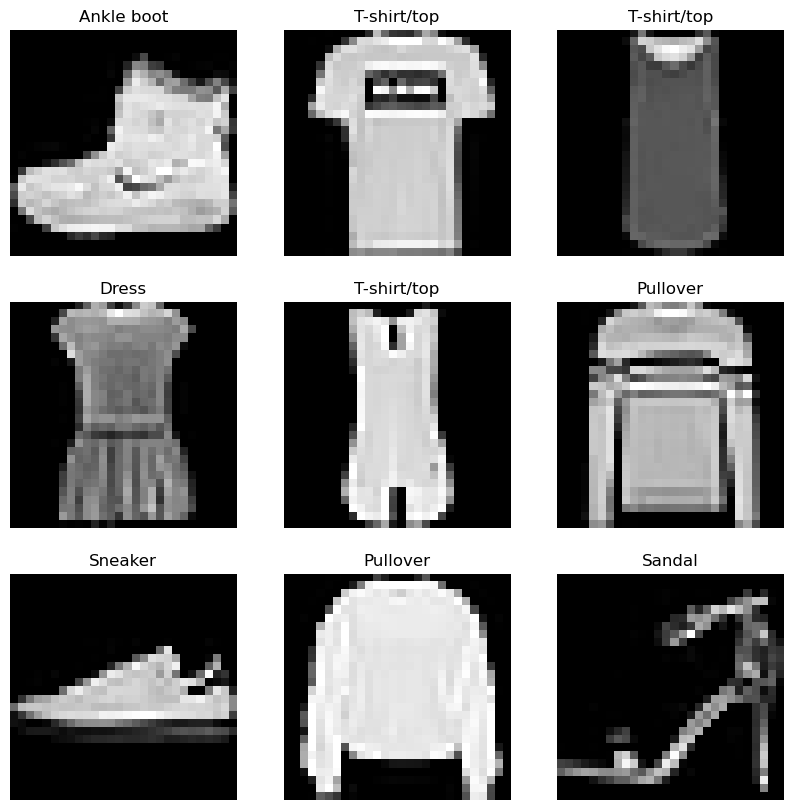

In [5]:
# Step 6: Display Sample Images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [6]:
# Step 7: Build Deep Neural Network Model
model = Sequential([
    Flatten(input_shape=(28,28)),
    
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    
    Dense(10, activation='softmax')
])


c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Step 8: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Step 9: Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8167 - loss: 0.5173 - val_accuracy: 0.8534 - val_loss: 0.4133
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8640 - loss: 0.3769 - val_accuracy: 0.8685 - val_loss: 0.3675
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8775 - loss: 0.3393 - val_accuracy: 0.8790 - val_loss: 0.3394
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8834 - loss: 0.3155 - val_accuracy: 0.8782 - val_loss: 0.3373
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8900 - loss: 0.2957 - val_accuracy: 0.8753 - val_loss: 0.3423
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8946 - loss: 0.2815 - val_accuracy: 0.8748 - val_loss: 0.3491
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8997 - loss: 0.2681 - val_accuracy: 0.8832 - val_loss: 0.3266
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9058 - loss: 0.2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8777 - loss: 0.3559

Test Accuracy : 0.8776999711990356
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.77      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.73      0.86      0.79      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.80      0.78      0.79      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.71      0.67      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.99      0.94      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



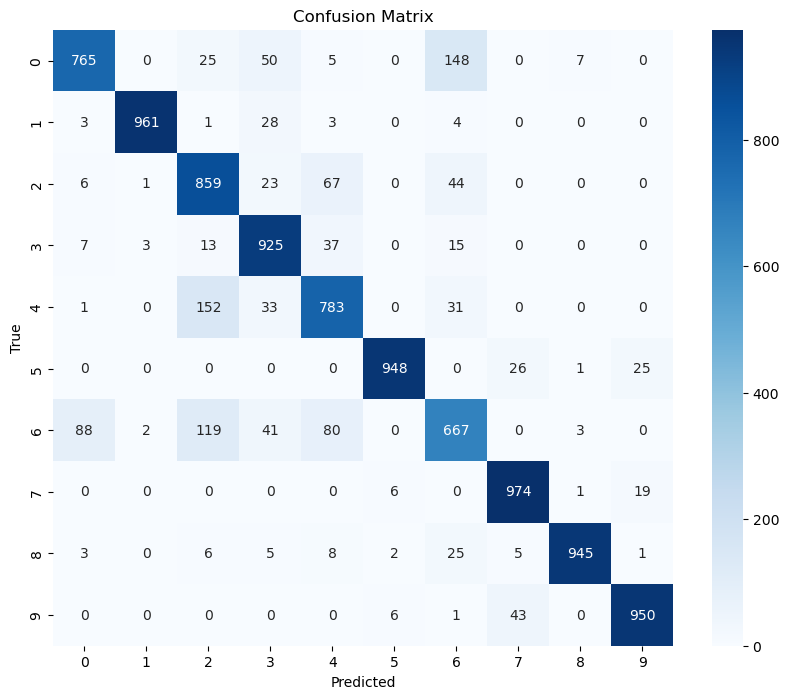

In [9]:
# Step 10: Evaluate Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy :", test_accuracy)

# Predictions and classification report
preds = model.predict(x_test)
y_pred = np.argmax(preds, axis=1)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [10]:
# Step 11: Predict on Test Data
predictions = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


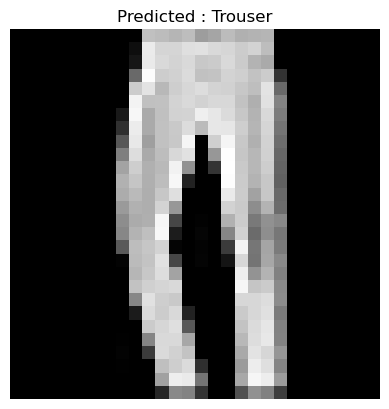

Actual Label    : Trouser
Predicted Label : Trouser


In [11]:
# Step 12: Show Prediction Example
index = 5

plt.imshow(x_test[index], cmap='gray')
plt.title("Predicted : " + class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

print("Actual Label    :", class_names[y_test[index]])
print("Predicted Label :", class_names[np.argmax(predictions[index])])

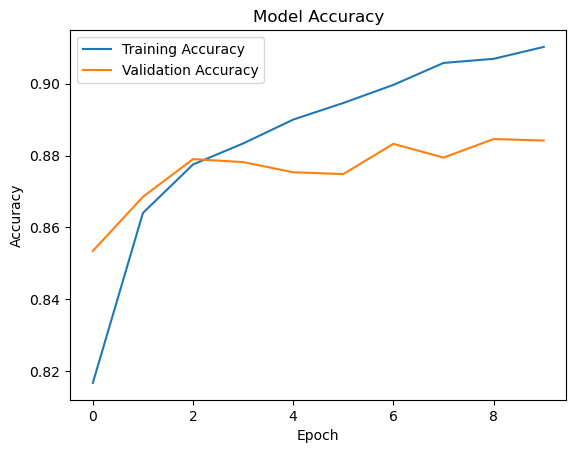

In [12]:
# Step 13: Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

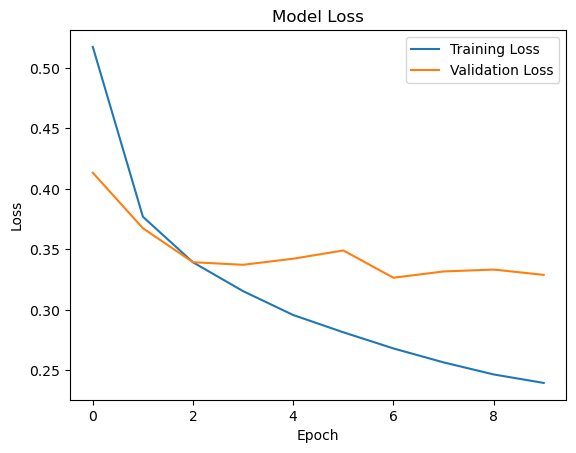

In [13]:
# Step 14: Plot Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()